In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import WeightedRandomSampler
from torchvision import transforms
from tqdm import tqdm

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
# ✅ Classes
SEASON_CLASSES = ['Spring', 'Summer', 'Autumn', 'Winter']

# ✅ Dataset
class PersonalColorDataset(Dataset):
    def __init__(self, csv_path, image_root, transform=None):
        self.data = pd.read_csv(csv_path)
        self.image_root = image_root
        self.transform = transform
        self.label_map = {season: idx for idx, season in enumerate(SEASON_CLASSES)}

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join(self.image_root, row['season'], row['filename'])
        image = Image.open(img_path).convert('RGB')
        label = self.label_map[row['season']]

        if self.transform:
            image = self.transform(image)

        return image, label

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_val_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_val_loss is None:
            self.best_val_loss = val_loss
        elif val_loss < self.best_val_loss - self.min_delta:
            self.best_val_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

In [3]:
# Image transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# Dataloaders
train_dataset = PersonalColorDataset(csv_path='dataset_fake_rm_bg/train.csv',image_root='dataset_fake_rm_bg',transform=train_transform)
val_dataset = PersonalColorDataset(csv_path='dataset_fake_rm_bg/val.csv', image_root='dataset_fake_rm_bg', transform=val_transform)
test_dataset = PersonalColorDataset(csv_path='dataset_fake_rm_bg/test.csv',image_root='dataset_fake_rm_bg',transform=val_transform)

# ✅ Class Weights
df = pd.read_csv('dataset_fake_rm_bg/train.csv')
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(df['season']), y=df['season'])
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

# Calculate weights for each sample
label_to_idx = {label: idx for idx, label in enumerate(SEASON_CLASSES)}
labels = df['season'].map(label_to_idx)
class_sample_counts = labels.value_counts().sort_index().values
class_weights = 1. / class_sample_counts
sample_weights = [class_weights[label] for label in labels]

sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# Replace train_loader
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)


🔍 Class Distribution in Training Set:
season
Spring    210
Summer    210
Autumn    210
Winter    179
Name: count, dtype: int64


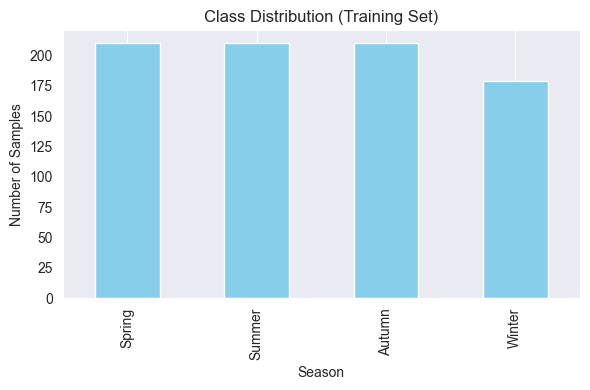

In [4]:
# Count class distribution
class_counts = df['season'].value_counts().reindex(SEASON_CLASSES)

# Print counts
print("🔍 Class Distribution in Training Set:")
print(class_counts)

# Plot as bar chart
plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar', color='skyblue')
plt.title("Class Distribution (Training Set)")
plt.xlabel("Season")
plt.ylabel("Number of Samples")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [10]:
from torchvision.models import efficientnet_b1, EfficientNet_B1_Weights

# ✅ Load pretrained EfficientNet-B1
weights = EfficientNet_B1_Weights.DEFAULT
model = efficientnet_b1(weights=weights)

# ✅ Replace classification head with Dropout
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, 4)
)

# ✅ Move model to device
model = model.to(device)

# ✅ Define weighted loss
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# ✅ Optimizer and Scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-5)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, verbose=True
)

# ✅ Improved EarlyStopping class
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_val_loss = None

    def __call__(self, val_loss):
        if self.best_val_loss is None:
            self.best_val_loss = val_loss
            return False
        elif val_loss < self.best_val_loss - self.min_delta:
            self.best_val_loss = val_loss
            self.counter = 0
            return False
        else:
            self.counter += 1
            print(f"⚠️ EarlyStopping counter: {self.counter}/{self.patience}")
            return self.counter >= self.patience

# ✅ Training Function
def train_model(model, train_loader, val_loader, epochs):
    early_stopper = EarlyStopping(patience=3, min_delta=0.0)
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": []
    }
    best_val_loss = float("inf")

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct, total = 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_acc = 100 * correct / total
        avg_loss = running_loss / len(train_loader)

        torch.cuda.empty_cache()

        # 🔍 Validation
        model.eval()
        val_loss = 0.0
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_acc = 100 * val_correct / val_total
        avg_val_loss = val_loss / len(val_loader)
        scheduler.step(avg_val_loss)

        history["train_loss"].append(avg_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(avg_val_loss)
        history["val_acc"].append(val_acc)

        print(f"[{epoch+1}/{epochs}] Train Loss: {avg_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%, Val Loss: {avg_val_loss:.4f}")

        # ✅ Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), "model/efficientnet1_best_model.pth")
            print("✅ Saved new best model")

        # ⛔ Early stopping
        if early_stopper(avg_val_loss):
            print("🛑 Early stopping triggered.")
            break

    return history

# ✅ Train
history = train_model(model, train_loader, val_loader, epochs=30)

# ✅ Save training history
import pickle
with open("history/efficientnet1_training_history.pkl", "wb") as f:
    pickle.dump(history, f)

/home/senghuyjr11/Drive/001_ML_Projects/color_analysis/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 1/30: 100%|██████████| 26/26 [00:13<00:00,  1.87it/s]


[1/30] Train Loss: 1.3590, Train Acc: 33.75%, Val Acc: 39.31%, Val Loss: 1.3376
✅ Saved new best model


Epoch 2/30: 100%|██████████| 26/26 [00:13<00:00,  1.92it/s]


[2/30] Train Loss: 1.2126, Train Acc: 52.04%, Val Acc: 53.76%, Val Loss: 1.1050
✅ Saved new best model


Epoch 3/30: 100%|██████████| 26/26 [00:14<00:00,  1.79it/s]


...

[8/30] Train Loss: 0.4461, Train Acc: 83.44%, Val Acc: 67.05%, Val Loss: 0.6898
⚠️ EarlyStopping counter: 1/3


Epoch 9/30: 100%|██████████| 26/26 [00:14<00:00,  1.86it/s]


[9/30] Train Loss: 0.4398, Train Acc: 83.56%, Val Acc: 68.79%, Val Loss: 0.7041
⚠️ EarlyStopping counter: 2/3


Epoch 10/30: 100%|██████████| 26/26 [00:14<00:00,  1.83it/s]


[10/30] Train Loss: 0.3437, Train Acc: 86.28%, Val Acc: 65.32%, Val Loss: 0.7541
⚠️ EarlyStopping counter: 3/3
🛑 Early stopping triggered.


In [11]:
from torchvision.models import efficientnet_b1, EfficientNet_B1_Weights

# ✅ Load EfficientNet-B1 structure with default weights
weights = EfficientNet_B1_Weights.DEFAULT
loaded_model = efficientnet_b1(weights=weights)

# ✅ Replace classifier head to match number of classes
loaded_model.classifier[1] = nn.Linear(loaded_model.classifier[1].in_features, 4)

# ✅ Load trained weights
loaded_model.load_state_dict(torch.load("model/efficientnet1_best_model.pth"))

# ✅ Move to device and set to eval mode
loaded_model = loaded_model.to(device)
loaded_model.eval()

print("✅ Best EfficientNet-B1 model loaded successfully")


✅ Best EfficientNet-B1 model loaded successfully


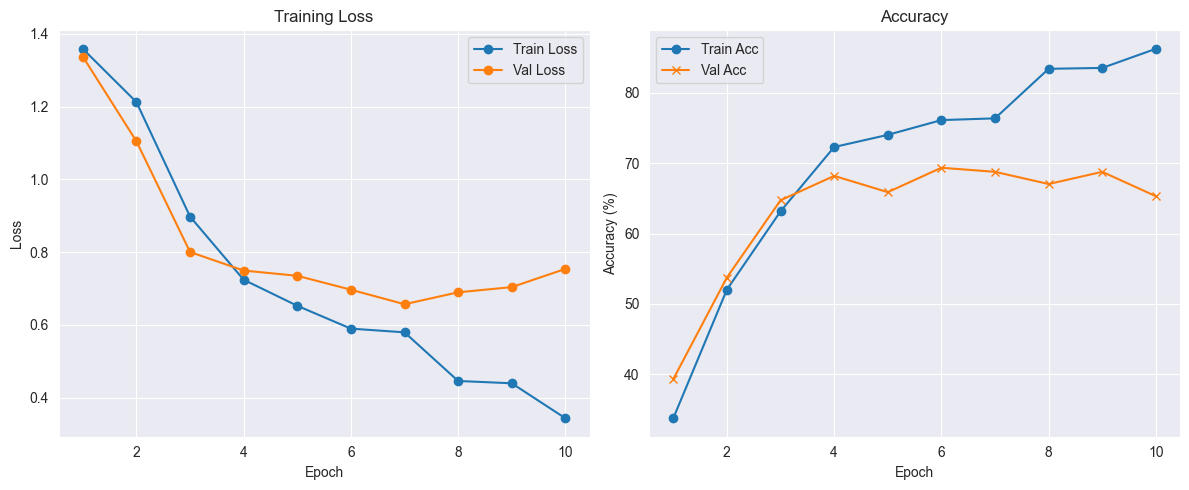

In [12]:
with open("history/efficientnet1_training_history.pkl", "rb") as f:
    history = pickle.load(f)


def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label='Train Loss', marker='o')
    plt.plot(epochs, history["val_loss"], label='Val Loss', marker='o')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label='Train Acc', marker='o')
    plt.plot(epochs, history["val_acc"], label='Val Acc', marker='x')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

Test Accuracy: 73.56%

Classification Report:
              precision    recall  f1-score   support

      Spring       0.75      0.84      0.79        45
      Summer       0.77      0.67      0.71        45
      Autumn       0.70      0.69      0.70        45
      Winter       0.72      0.74      0.73        39

    accuracy                           0.74       174
   macro avg       0.74      0.74      0.73       174
weighted avg       0.74      0.74      0.73       174



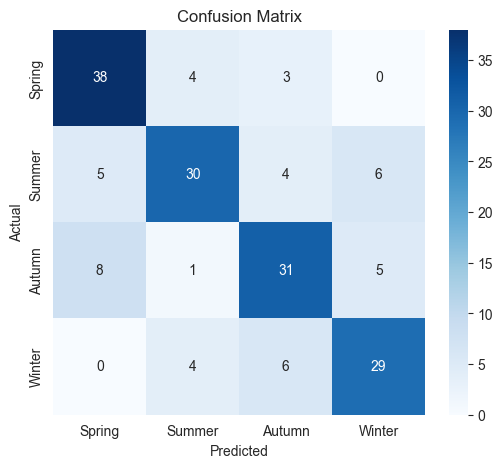

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Accuracy
    total = len(all_labels)
    correct = sum(p == l for p, l in zip(all_preds, all_labels))
    acc = 100 * correct / total
    print(f"Test Accuracy: {acc:.2f}%")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=SEASON_CLASSES))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=SEASON_CLASSES, yticklabels=SEASON_CLASSES)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

evaluate_model(loaded_model, test_loader)